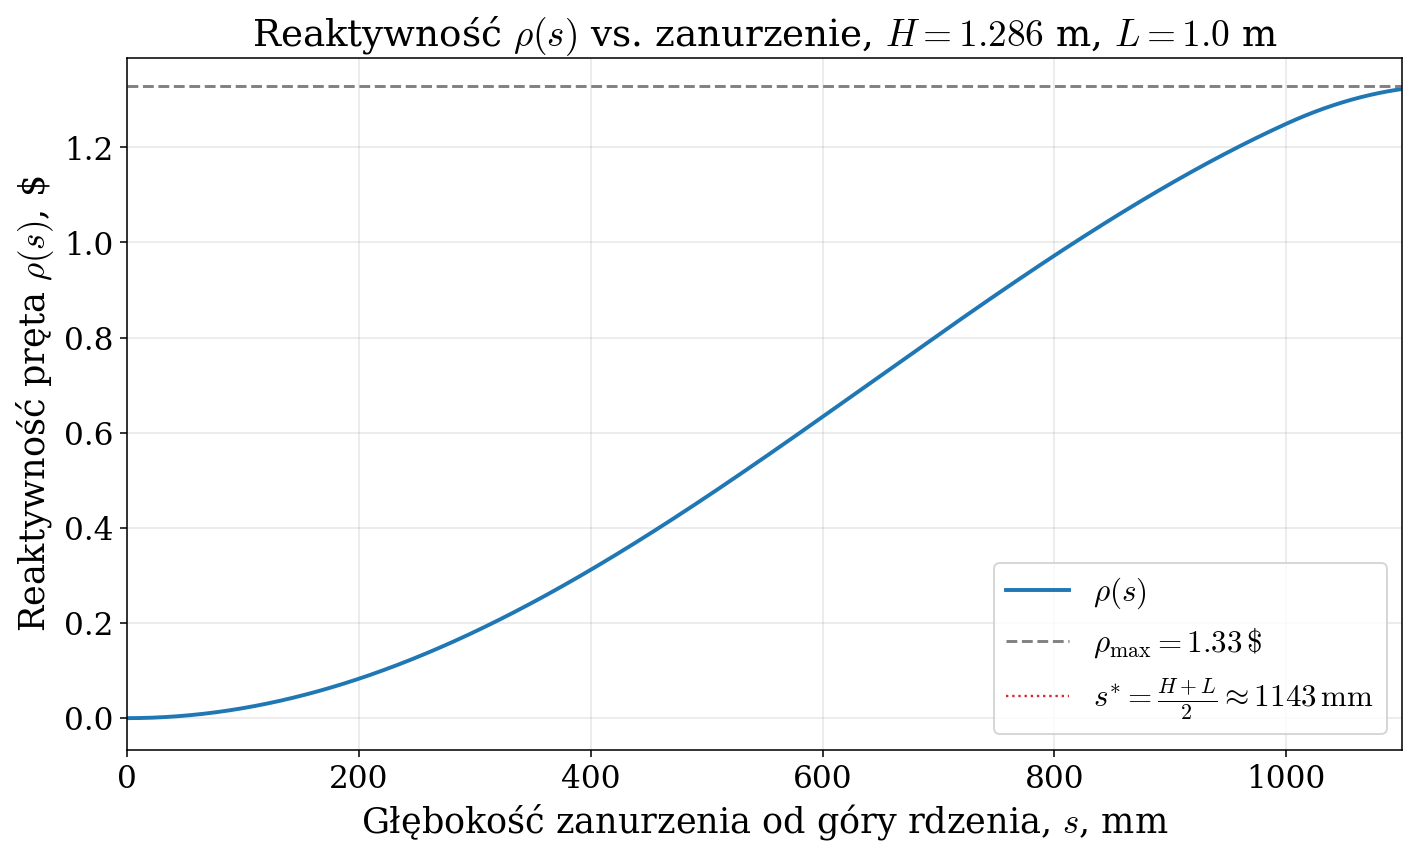

In [1]:
# ===============================================
#  Reaktywność pręta ρ(s) vs. zanurzenie (bez nawiasów jednostek)
#  H=1.286 m, L=1.0 m; ρ_max podaje użytkownik (w $)
# ===============================================
from __future__ import annotations
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ładna typografia bez LaTeXa
mpl.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'CMU Serif', 'Libertinus Serif', 'Nimbus Roman'],
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
    'figure.dpi': 140, 'savefig.dpi': 300,
    'font.size': 16, 'axes.labelsize': 18
})

# --- dane geometryczne ---
H = 1.286  # m (ekstrapolowana wysokość rdzenia)
L = 1.000  # m (długość pręta PK)

# ====> TU PODAJ SWOJE MAKSYMALNE ρ (w $) <====
RHO_MAX_USER = 1.33  # np. 0.85, 1.20 itd.

# --- efektywność pręta (krzywa geometryczna przed skalowaniem) ---
def rho_pk_geom_from_depth(s, H=H, L=L):
    """
    s [m] – głębokość zanurzenia liczona od GÓRY rdzenia (w dół).
    Zwraca ϱ_pk(s) = (H/π)[sin(π*stop/H) - sin(π*start/H)] dla części pręta w rdzeniu.
    """
    s = np.asarray(s, dtype=float)
    z_bottom = H/2 - s        # dolny koniec pręta
    z_top    = z_bottom + L   # górny koniec pręta

    start = np.maximum(z_bottom, -H/2)
    stop  = np.minimum(z_top,    H/2)

    res = (H/np.pi) * (np.sin(np.pi*stop/H) - np.sin(np.pi*start/H))
    return np.where(stop > start, res, 0.0)

# --- teoretyczne maksimum krzywej geometrycznej (dla kosinusa) ---
rho_max_geom = (2*H/np.pi) * np.sin(np.pi*L/(2*H))

# --- siatka zanurzeń 0..1100 mm ---
s_mm = np.linspace(0, 1100, 1101)
s_m  = s_mm / 1000.0
rpk_geom = rho_pk_geom_from_depth(s_m)

# --- skalowanie do dolarów: maksimum = RHO_MAX_USER ($) ---
scale = RHO_MAX_USER / rho_max_geom
rho_dollars = rpk_geom * scale

# --- gdzie przypada maksimum (środek pręta w z=0): s* = (H+L)/2 ---
s_star_mm = (H + L)/2 * 1000.0

# --- wykres ---
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# krzywa ρ(s)
ax.plot(s_mm, rho_dollars, lw=2, label=r"$\rho(s)$")

# pozioma linia ρ_max (z jednostką bez nawiasów)
ax.axhline(RHO_MAX_USER, ls="--", lw=1.5, color="gray",
           label=fr"$\rho_{{\max}} = {RHO_MAX_USER}\,\$$")

# pionowa linia w s*
ax.axvline(s_star_mm, ls=":", lw=1.2, color="tab:red",
           label=fr"$s^{{*}}=\frac{{H+L}}{{2}} \approx {s_star_mm:.0f}\,\mathrm{{mm}}$")

ax.set_xlim(0, 1100)
ax.set_xlabel(r"Głębokość zanurzenia od góry rdzenia, $s$, mm")
ax.set_ylabel(r"Reaktywność pręta $\rho(s)$, \$")
ax.set_title(fr"Reaktywność $\rho(s)$ vs. zanurzenie, $H={H}$ m, $L={L}$ m")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()




